In [4]:
from mGST.low_level_jit import cost_function_jax_mps
from mGST.utility_functions_comparisons import get_compressed_rep_from_mgst_output

from iqm.benchmarks.compressive_gst.compressive_gst import GSTConfiguration
from mGST.utility_functions_comparisons import get_full_mgst_parameters_from_configuration, create_4q_gst_config
from mGST.visualization import plot_wall_time
from mGST.automatic_diff import automatic_gradient, hvp
import jax.numpy as jnp
import jax

backend = "iqmfakeapollo"
data_path = "../data/"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Goal

I have had in mind for a while to implement a different contraction for the case when the quantum channel is rank = 1 (coherent error).

According to my complexity analysis, the current contraction (MPS - zigzag) is optimal for general rank r, but for r = 1, it is actually more beneficial to contract along the bond dimension and then contract with its adjoint.

Let's test this out

# Tensor generation

In [8]:
# fixed kraus rank to really the dependence in the system size dimension
kraus_rank = 1
shots = 1000
# In general, the max kraus rank would be dim**2 with dim = 2**n_qubits

In [ ]:
# First using the JAX compilation with smaller qubits to see if this helps
dim_1q = 2
num_circuits_1q = 100

Q1_GST = GSTConfiguration(
    qubit_layouts=[[0]],
    gate_set="1QXYI",
    num_circuits=num_circuits_1q,
    shots=shots,
    rank=kraus_rank,
)

kraus_tensor_mgst_1q, kraus_mgst_1q, povm_mgst_1q, state_mgst_1q, prob_matrix_1q, indices_list_1q = get_full_mgst_parameters_from_configuration(
    Q1_GST, backend, only_jax_variables=True
)

kraus_tensor_1q_target, povm_psd_1q_target, state_psd_1q_target = get_compressed_rep_from_mgst_output(kraus_mgst_1q, povm_mgst_1q, state_mgst_1q, kraus_rank=kraus_rank, state_rank=dim_1q, povm_rank=dim_1q)


2026-02-02 17:12:15,667 - iqm.benchmarks.logging_config - INFO - Generating 100 random GST circuits
2026-02-02 17:12:15,897 - iqm.benchmarks.logging_config - INFO - Will transpile all 100 circuits according to fixed physical layout
2026-02-02 17:12:15,927 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2026-02-02 17:12:16,526 - iqm.benchmarks.logging_config - INFO - Submitting batch with 100 circuits corresponding to qubits [0]
2026-02-02 17:12:16,535 - iqm.benchmarks.logging_config - INFO - Stored jobs for 1 layouts in dataset
2026-02-02 17:12:16,547 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2026-02-02 17:12:16,625 - iqm.benchmarks.logging_config - INFO - Retrieving all counts
2026-02-02 17:12:16,956 - iqm.benchmarks.logging_config - INFO - Adding counts to dataset
2026-02-02 17:12:17,057 - iqm.benchmarks.logging_config - INFO - Run completed


In [11]:
dim_2q = 2**2
num_circuits_2q = 800

Q2_GST = GSTConfiguration(
    qubit_layouts=[[0, 1]],
    gate_set="2QXYICZ",
    num_circuits=num_circuits_2q,
    shots=shots,
    rank=kraus_rank,
)

kraus_tensor_mgst_2q, kraus_mgst_2q, povm_mgst_2q, state_mgst_2q, prob_matrix_2q, indices_list_2q = get_full_mgst_parameters_from_configuration(
    Q2_GST, backend, only_jax_variables=True
)

kraus_tensor_2q_target, povm_psd_2q_target, state_psd_2q_target = get_compressed_rep_from_mgst_output(kraus_mgst_2q, povm_mgst_2q, state_mgst_2q, kraus_rank=kraus_rank, state_rank=dim_2q, povm_rank=dim_2q)

2026-02-02 17:24:33,756 - iqm.benchmarks.logging_config - INFO - Generating 800 random GST circuits
2026-02-02 17:24:34,344 - iqm.benchmarks.logging_config - INFO - Will transpile all 800 circuits according to fixed physical layout
2026-02-02 17:24:34,537 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2026-02-02 17:24:36,731 - iqm.benchmarks.logging_config - INFO - Submitting batch with 800 circuits corresponding to qubits [0, 1]
2026-02-02 17:24:36,732 - iqm.benchmarks.logging_config - INFO - Stored jobs for 1 layouts in dataset
2026-02-02 17:24:36,786 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2026-02-02 17:24:36,817 - iqm.benchmarks.logging_config - INFO - Retrieving all counts
2026-02-02 17:24:37,788 - iqm.benchmarks.logging_config - INFO - Adding counts to dataset
2026-02-02 17:24:39,365 - iqm.benchmarks.logging_config - INFO - Run complet

In [12]:
dim_3q = 2**3
num_circuits_3q = 1000

Q3_GST = GSTConfiguration(
    qubit_layouts=[[0,1,3]],
    gate_set="3QXYCZ",
    num_circuits=num_circuits_3q,
    shots=shots,
    rank=kraus_rank,
)

kraus_tensor_mgst_3q, kraus_mgst_3q, povm_mgst_3q, state_mgst_3q, prob_matrix_3q, indices_list_3q = get_full_mgst_parameters_from_configuration(
    Q3_GST, backend, only_jax_variables=True
)

kraus_tensor_3q_target, povm_psd_3q_target, state_psd_3q_target = get_compressed_rep_from_mgst_output(kraus_mgst_3q, povm_mgst_3q, state_mgst_3q, kraus_rank=kraus_rank, state_rank=dim_3q, povm_rank=dim_3q)

2026-02-02 17:26:00,190 - iqm.benchmarks.logging_config - INFO - Generating 1000 random GST circuits
2026-02-02 17:26:00,398 - iqm.benchmarks.logging_config - INFO - Will transpile all 1000 circuits according to fixed physical layout
2026-02-02 17:26:01,217 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2026-02-02 17:26:03,865 - iqm.benchmarks.logging_config - INFO - Submitting batch with 1000 circuits corresponding to qubits [0, 1, 3]
2026-02-02 17:26:03,866 - iqm.benchmarks.logging_config - INFO - Stored jobs for 1 layouts in dataset
2026-02-02 17:26:03,928 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2026-02-02 17:26:03,984 - iqm.benchmarks.logging_config - INFO - Retrieving all counts
2026-02-02 17:26:05,535 - iqm.benchmarks.logging_config - INFO - Adding counts to dataset
2026-02-02 17:26:07,745 - iqm.benchmarks.logging_config - INFO - Run c

In [19]:
dim_4q = 2**4
num_gate_sequences_4q = 2000

Q4_GST = create_4q_gst_config(
    kraus_rank=kraus_rank,
    num_gate_sequences=num_gate_sequences_4q,
    shots=shots,
    seq_len_list=[1, 10, 19],
    )

In [20]:
kraus_tensor_mgst_4q, kraus_mgst_4q, povm_mgst_4q, state_mgst_4q, prob_matrix_4q, indices_list_4q = get_full_mgst_parameters_from_configuration(
    Q4_GST, backend, only_jax_variables=True
)

kraus_tensor_4q_target, povm_psd_4q_target, state_psd_4q_target = get_compressed_rep_from_mgst_output(kraus_mgst_4q, povm_mgst_4q, state_mgst_4q, kraus_rank=kraus_rank, state_rank=dim_4q, povm_rank=dim_4q)

2026-02-02 18:05:41,177 - iqm.benchmarks.logging_config - INFO - Generating 2000 random GST circuits
2026-02-02 18:05:42,234 - iqm.benchmarks.logging_config - INFO - Will transpile all 2000 circuits according to fixed physical layout
2026-02-02 18:05:42,999 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2026-02-02 18:05:47,070 - iqm.benchmarks.logging_config - INFO - Submitting batch with 2000 circuits corresponding to qubits [0, 1, 3, 4]
2026-02-02 18:05:47,074 - iqm.benchmarks.logging_config - INFO - Stored jobs for 1 layouts in dataset
2026-02-02 18:05:47,138 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2026-02-02 18:05:47,207 - iqm.benchmarks.logging_config - INFO - Retrieving all counts
2026-02-02 18:05:50,711 - iqm.benchmarks.logging_config - INFO - Adding counts to dataset
2026-02-02 18:05:57,782 - iqm.benchmarks.logging_config - INFO - Ru

In [22]:
input_1q = {
    "kraus_tensor": kraus_tensor_1q_target,
    "povm_psd": povm_psd_1q_target,
    "state_psd": state_psd_1q_target,
    "prob_matrix": prob_matrix_1q,
    "indices_list": indices_list_1q,
}

input_2q = {
    "kraus_tensor": kraus_tensor_2q_target,
    "povm_psd": povm_psd_2q_target,
    "state_psd": state_psd_2q_target,
    "prob_matrix": prob_matrix_2q,
    "indices_list": indices_list_2q,
}

input_3q = {
    "kraus_tensor": kraus_tensor_3q_target,
    "povm_psd": povm_psd_3q_target,
    "state_psd": state_psd_3q_target,
    "prob_matrix": prob_matrix_3q,
    "indices_list": indices_list_3q,
}

input_4q = {
    "kraus_tensor": kraus_tensor_4q_target,
    "povm_psd": povm_psd_4q_target,
    "state_psd": state_psd_4q_target,
    "prob_matrix": prob_matrix_4q,
    "indices_list": indices_list_4q,   
}

print(len(indices_list_1q[-1]), len(indices_list_2q[-1]), len(indices_list_3q[-1]), len(indices_list_4q[-1]))
print(len(indices_list_1q), len(indices_list_2q), len(indices_list_3q), len(indices_list_4q))
print(prob_matrix_1q.shape, prob_matrix_2q.shape, prob_matrix_3q.shape, prob_matrix_4q.shape)

prob_matrices = [prob_matrix_1q, prob_matrix_2q, prob_matrix_3q, prob_matrix_4q]
num_sequences_list = [matrix.shape[1] for matrix in prob_matrices]
num_povms = [matrix.shape[0] for matrix in prob_matrices]

num_povms, num_sequences_list

14 14 14 19
100 800 1000 2000
(2, 100) (4, 800) (8, 1000) (16, 2000)


([2, 4, 8, 16], [100, 800, 1000, 2000])

# Coherent cost function

In [44]:
from mGST.low_level_jit import cost_function_mps_single_gate_sequence_coherent, cost_function_mps_single_gate_sequence_coherent_jit

def cost_function_jax_mps_coherent(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix, jit=False):
    """Compute the cost function using jax and mps contraction strategy.
    
    Optimized using the most scalable jnp functions.

    Args:
        kraus: kraus tensor of dimensions (num_gates, kraus_rank, dim_out, dim_in)
        povm_psd: Positive-semidefinite (PSD) root of the POVM tensor of dimensions: (num_povm, rank_povm, dim)
        state_psd: Positive-semidefinite (PSD) factor of the state of dimensions: (dim, rank_state)
            (see B in Eq. 9 of mGST paper)
        indices_list: list of length num_gate_sequences, where each elements is a list of indices corresponding to a gate sequence.
        prob_matrix: tensor of dimensions (num_povm, num_gate_sequences)
    """
    cost_value = 0
    num_gate_sequences = len(indices_list)
    num_povm = povm_psd.shape[0]
    
    if jit:
        inner_function = cost_function_mps_single_gate_sequence_coherent_jit
    else:
        inner_function = cost_function_mps_single_gate_sequence_coherent
        
    for idx, gates_indices in enumerate(indices_list):
        cost_value += inner_function(kraus_tensor, povm_psd, state_psd, gates_indices, prob_matrix[:,idx])
    return cost_value / (num_gate_sequences * num_povm)

In [ ]:
# Just checking they even give the same value:
cost_jax_1q_coherent = cost_function_jax_mps_coherent(**input_1q)
cost_jax_2q_coherent = cost_function_jax_mps_coherent(**input_2q)
cost_jax_3q_coherent = cost_function_jax_mps_coherent(**input_3q)
cost_jax_4q_coherent = cost_function_jax_mps_coherent(**input_4q)

In [26]:
# Now for the general contraction
cost_jax_1q = cost_function_jax_mps(jit=False, **input_1q)
cost_jax_2q = cost_function_jax_mps(jit=False, **input_2q)
cost_jax_3q = cost_function_jax_mps(jit=False, **input_3q)
cost_jax_4q = cost_function_jax_mps(jit=False, **input_4q)

In [27]:
cost_coherent_list = [cost_jax_1q_coherent, cost_jax_2q_coherent, cost_jax_3q_coherent, cost_jax_4q_coherent]
cost_list = [cost_jax_1q, cost_jax_2q, cost_jax_3q, cost_jax_4q]

[jnp.allclose(cost_coherent, cost) for cost_coherent, cost in zip(cost_coherent_list, cost_list)]

[Array(True, dtype=bool),
 Array(True, dtype=bool),
 Array(True, dtype=bool),
 Array(True, dtype=bool)]

# Compiling functions

In [43]:
# To let them compile
cost_1q = cost_function_jax_mps(jit=True, **input_1q)
cost_2q = cost_function_jax_mps(jit=True, **input_2q)
cost_3q = cost_function_jax_mps(jit=True, **input_3q)
cost_4q = cost_function_jax_mps(jit=True, **input_4q)

at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 4 the new count changed to: 3
at iteration 10 the new count changed to: 4
at iteration 16 the new count changed to: 5
at iteration 22 the new count changed to: 6
at iteration 29 the new count changed to: 7
at iteration 36 the new count changed to: 8
at iteration 43 the new count changed to: 9
at iteration 50 the new count changed to: 10
at iteration 58 the new count changed to: 11
at iteration 66 the new count changed to: 12
at iteration 74 the new count changed to: 13
at iteration 82 the new count changed to: 14
at iteration 91 the new count changed to: 15
at iteration 0 the new count changed to: 16
at iteration 1 the new count changed to: 17
at iteration 7 the new count changed to: 18
at iteration 43 the new count changed to: 19
at iteration 102 the new count changed to: 20
at iteration 161 the new count changed to: 21
at iteration 220 the new count changed to: 22
at iteration 280 the n

In [45]:
# To let them compile
cost_1q_coherent = cost_function_jax_mps_coherent(jit=True, **input_1q)
cost_2q_coherent = cost_function_jax_mps_coherent(jit=True, **input_2q)
cost_3q_coherent = cost_function_jax_mps_coherent(jit=True, **input_3q)
cost_4q_coherent = cost_function_jax_mps_coherent(jit=True, **input_4q)

In [46]:
# just checking they are all the same as well
coherent_list_jit = [cost_1q_coherent, cost_2q_coherent, cost_3q_coherent, cost_4q_coherent]
cost_list_jit = [cost_1q, cost_2q, cost_3q, cost_4q]
[jnp.allclose(cost_coherent, cost) for cost_coherent, cost in zip(coherent_list_jit, cost_list_jit)]

[Array(True, dtype=bool),
 Array(True, dtype=bool),
 Array(True, dtype=bool),
 Array(True, dtype=bool)]

# Timeit

In [28]:
timing_cost_1q_coherent = %timeit -o cost_function_jax_mps_coherent(**input_1q)
timing_cost_2q_coherent = %timeit -o cost_function_jax_mps_coherent(**input_2q)
timing_cost_3q_coherent = %timeit -o cost_function_jax_mps_coherent(**input_3q)
timing_cost_4q_coherent = %timeit -o cost_function_jax_mps_coherent(**input_4q)

47.3 ms ± 225 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
381 ms ± 1.75 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
572 ms ± 28.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.32 s ± 16.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [47]:
timing_cost_1q_coherent_jit = %timeit -o cost_function_jax_mps_coherent(jit=True, **input_1q)
timing_cost_2q_coherent_jit = %timeit -o cost_function_jax_mps_coherent(jit=True, **input_2q)
timing_cost_3q_coherent_jit = %timeit -o cost_function_jax_mps_coherent(jit=True, **input_3q)
timing_cost_4q_coherent_jit = %timeit -o cost_function_jax_mps_coherent(jit=True, **input_4q)

1.91 ms ± 12.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
28.5 ms ± 1.94 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
37.4 ms ± 1.5 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
159 ms ± 3.06 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [23]:
timing_cost_1q_no_jit = %timeit -o cost_function_jax_mps(jit=False, **input_1q)
timing_cost_2q_no_jit = %timeit -o cost_function_jax_mps(jit=False, **input_2q)
timing_cost_3q_no_jit = %timeit -o cost_function_jax_mps(jit=False, **input_3q)
timing_cost_4q_no_jit = %timeit -o cost_function_jax_mps(jit=False, **input_4q)

134 ms ± 22.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
984 ms ± 5.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.3 s ± 13.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
3.45 s ± 28.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [48]:
# Store timing result in a variable
timing_1q_jit = %timeit -o cost_function_jax_mps(jit=True, **input_1q)
timing_2q_jit = %timeit -o cost_function_jax_mps(jit=True, **input_2q)
timing_3q_jit = %timeit -o cost_function_jax_mps(jit=True, **input_3q)
timing_4q_jit = %timeit -o cost_function_jax_mps(jit=True, **input_4q)

2.27 ms ± 12.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
28.7 ms ± 3.53 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
36.5 ms ± 1.3 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
220 ms ± 761 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [49]:
timings_coherent_no_jit = [timing_cost_1q_coherent, timing_cost_2q_coherent, timing_cost_3q_coherent, timing_cost_4q_coherent]
timings_coherent_jit = [timing_cost_1q_coherent_jit, timing_cost_2q_coherent_jit, timing_cost_3q_coherent_jit, timing_cost_4q_coherent_jit]

timings_incoherent_no_jit = [timing_cost_1q_no_jit, timing_cost_2q_no_jit, timing_cost_3q_no_jit, timing_cost_4q_no_jit]
timings_incoherent_jit = [timing_1q_jit, timing_2q_jit, timing_3q_jit, timing_4q_jit]

# Plot

In [50]:
tuples_incoherent = [(time.average, time.stdev) for time in timings_incoherent]
tuples_incoherent_jit = [(time.average, time.stdev) for time in timings_incoherent_jit]

tuples_coherent = [(time.average, time.stdev) for time in timings_coherent]
tuples_coherent_jit = [(time.average, time.stdev) for time in timings_coherent_jit]

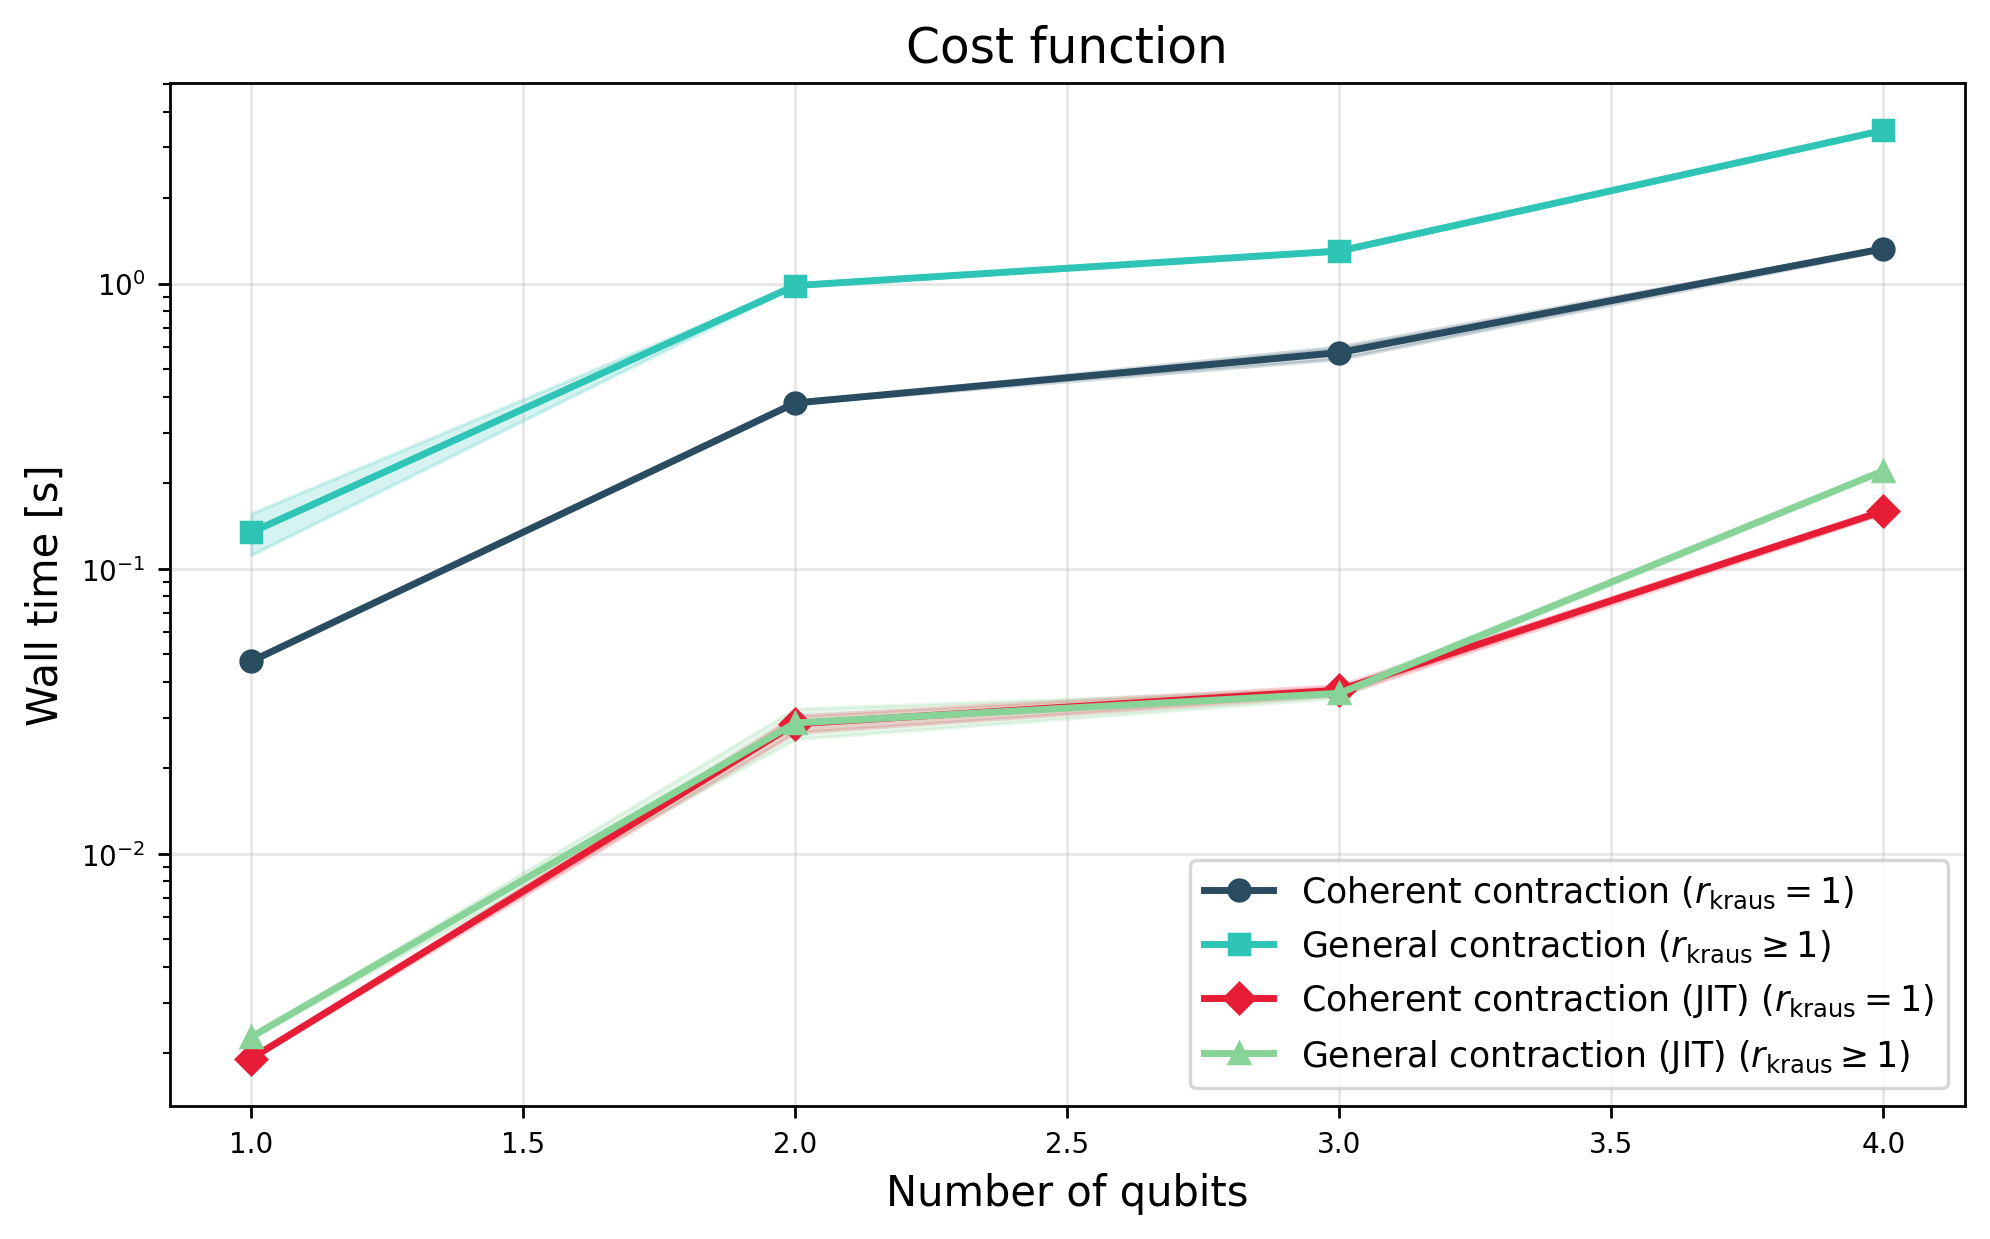

In [53]:
cost_fn_times = {
    r"Coherent contraction ($r_{\mathrm{kraus}} = 1$)": tuples_coherent,
    r"General contraction ($r_{\mathrm{kraus}} \geq 1$)": tuples_incoherent,
    r"Coherent contraction (JIT) ($r_{\mathrm{kraus}} = 1$)": tuples_coherent_jit,
    r"General contraction (JIT) ($r_{\mathrm{kraus}} \geq 1$)": tuples_incoherent_jit,
}

num_qubits = [1, 2, 3, 4]

plot_wall_time(cost_fn_times, num_qubits, logscale="y", title="Cost function")

In [41]:
# We have added automatic coherent detection in the cost functio.
# Let's test it

cost_function_jax_mps(**input_1q)

/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/low_level_jit.py:590: UserWarning: Kraus rank = 1 detected. Using the coherent version of the cost function for better performance.
  warnings.warn("Kraus rank = 1 detected. Using the coherent version of the cost function for better performance.")


Array(0.01638783, dtype=float64)

In [42]:
cost_function_jax_mps(**input_1q, jit=True)

/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/low_level_jit.py:590: UserWarning: Kraus rank = 1 detected. Using the coherent version of the cost function for better performance.
  warnings.warn("Kraus rank = 1 detected. Using the coherent version of the cost function for better performance.")


at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 4 the new count changed to: 3
at iteration 10 the new count changed to: 4
at iteration 16 the new count changed to: 5
at iteration 22 the new count changed to: 6
at iteration 29 the new count changed to: 7
at iteration 36 the new count changed to: 8
at iteration 43 the new count changed to: 9
at iteration 50 the new count changed to: 10
at iteration 58 the new count changed to: 11
at iteration 66 the new count changed to: 12
at iteration 74 the new count changed to: 13
at iteration 82 the new count changed to: 14
at iteration 91 the new count changed to: 15


Array(0.01638783, dtype=float64)